In [50]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

In [51]:


# Login using e.g. `huggingface-cli login` to access this dataset
splits = {'train': 'train.tsv', 'validation': 'dev.tsv'}
df_train = pd.read_csv("hf://datasets/s-nlp/ru_paradetox/" + splits["train"], sep="\t")
df_val = pd.read_csv("hf://datasets/s-nlp/ru_paradetox/" + splits["validation"], sep="\t")

In [52]:
df_train.head()

,ru_toxic_comment,ru_neutral_comment
0,"и,чё,блядь где этот херой был до этого со свои...","Ну и где этот герой был,со своими доказательст..."
1,"и,чё,блядь где этот херой был до этого со свои...",Где этот герой был до этого со своими доказате...
2,"и,чё,блядь где этот херой был до этого со свои...","и,где этот герой был до этого со своими доказа..."
3,"О, а есть деанон этого петуха?","О, а есть деанон"
4,"херну всякую пишут,из-за этого лайка.долбоебизм.","Чушь всякую пишут, из- за этого лайка."


In [53]:
df_val.head()

,ru_toxic_comment,ru_neutral_comment
0,пиздеж! температуры горения хватит чтобы её ра...,Враньё! Температуры горения хватит чтобы ее ра...
1,пиздеж! температуры горения хватит чтобы её ра...,"неправда,температуры горения хватит чтобы расп..."
2,пиздеж! температуры горения хватит чтобы её ра...,Враньё! Температуры горения хватит на чтобы её...
3,а ты чмо там был.ты вообще служил.гандон,А ты там был? Ты вообще служил?
4,пиздабол ---- а сам где кормишься ?,а сам где кормишься ?


In [54]:
print("Train shape:", df_train.shape)
print("Validation shape:", df_val.shape)

Train shape: (11090, 2)
Validation shape: (1116, 2)


In [55]:
df_train.describe(include='object')

,ru_toxic_comment,ru_neutral_comment
count,11090,11090
unique,6948,10873
top,"и,чё,блядь где этот херой был до этого со свои...",Я там через день бываю
freq,3,3


In [56]:
df_val.describe(include='object')

,ru_toxic_comment,ru_neutral_comment
count,1116,1116
unique,800,1087
top,пиздеж! температуры горения хватит чтобы её ра...,как его вообще со стадиона выпустили
freq,3,2


In [57]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11090 entries, 0 to 11089
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ru_toxic_comment    11090 non-null  object
 1   ru_neutral_comment  11090 non-null  object
dtypes: object(2)
memory usage: 173.4+ KB


In [58]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116 entries, 0 to 1115
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ru_toxic_comment    1116 non-null   object
 1   ru_neutral_comment  1116 non-null   object
dtypes: object(2)
memory usage: 17.6+ KB


In [59]:
print("Train missing values:")
print(df_train.isnull().sum())

print("\nValidation missing values:")
print(df_val.isnull().sum())

Train missing values:
ru_toxic_comment      0
ru_neutral_comment    0
dtype: int64

Validation missing values:
ru_toxic_comment      0
ru_neutral_comment    0
dtype: int64


In [60]:
print("Train duplicates:", df_train.duplicated().sum())
print("Validation duplicates:", df_val.duplicated().sum())

Train duplicates: 207
Validation duplicates: 29


In [61]:
print("Train duplicate rows by toxic comment:", df_train["ru_toxic_comment"].duplicated().sum())
print("Train duplicate rows by neutral comment:", df_train["ru_neutral_comment"].duplicated().sum())

Train duplicate rows by toxic comment: 4142
Train duplicate rows by neutral comment: 217


In [62]:
print("Train duplicate pairs:", df_train.duplicated(subset=["ru_toxic_comment", "ru_neutral_comment"]).sum())
print("Validation duplicate pairs:", df_val.duplicated(subset=["ru_toxic_comment", "ru_neutral_comment"]).sum())

Train duplicate pairs: 207
Validation duplicate pairs: 29


Объединение train и validation для EDA

In [63]:
df_train["split"] = "train"
df_val["split"] = "validation"

df = pd.concat([df_train, df_val], ignore_index=True)
df.head()

,ru_toxic_comment,ru_neutral_comment,split
0,"и,чё,блядь где этот херой был до этого со свои...","Ну и где этот герой был,со своими доказательст...",train
1,"и,чё,блядь где этот херой был до этого со свои...",Где этот герой был до этого со своими доказате...,train
2,"и,чё,блядь где этот херой был до этого со свои...","и,где этот герой был до этого со своими доказа...",train
3,"О, а есть деанон этого петуха?","О, а есть деанон",train
4,"херну всякую пишут,из-за этого лайка.долбоебизм.","Чушь всякую пишут, из- за этого лайка.",train


Проверка на аномалии

In [64]:
text_cols = ["ru_toxic_comment", "ru_neutral_comment"]
len_cols = ["toxic_len_words", "neutral_len_words"]

df_checked = df.copy()



for col in text_cols:
    df_checked[col] = df_checked[col].where(df_checked[col].notna(), "")
    df_checked[col] = df_checked[col].astype(str)

df_checked["toxic_len_words"] = df_checked["ru_toxic_comment"].str.split().str.len()
df_checked["neutral_len_words"] = df_checked["ru_neutral_comment"].str.split().str.len()

for col in len_cols:
    df_checked[col] = pd.to_numeric(df_checked[col], errors="coerce")



anomalies = {}



anomalies["missing_toxic"] = df["ru_toxic_comment"].isna().sum()
anomalies["missing_neutral"] = df["ru_neutral_comment"].isna().sum()

anomalies["empty_toxic"] = (df_checked["ru_toxic_comment"].str.strip() == "").sum()
anomalies["empty_neutral"] = (df_checked["ru_neutral_comment"].str.strip() == "").sum()

anomalies["toxic_len_1"] = (df_checked["toxic_len_words"] == 1).sum()
anomalies["toxic_len_2"] = (df_checked["toxic_len_words"] == 2).sum()
anomalies["neutral_len_1"] = (df_checked["neutral_len_words"] == 1).sum()
anomalies["neutral_len_2"] = (df_checked["neutral_len_words"] == 2).sum()

anomalies["toxic_len_gt_25"] = (df_checked["toxic_len_words"] > 25).sum()
anomalies["neutral_len_gt_25"] = (df_checked["neutral_len_words"] > 25).sum()

anomalies["toxic_len_lt_neutral"] = (df_checked["toxic_len_words"] < df_checked["neutral_len_words"]).sum()
anomalies["toxic_len_eq_neutral"] = (df_checked["toxic_len_words"] == df_checked["neutral_len_words"]).sum()

anomalies["error_like_toxic"] = df_checked["ru_toxic_comment"].str.contains(
    r"error|#ERROR!",
    case=False,
    regex=True,
    na=False
).sum()

anomalies["error_like_neutral"] = df_checked["ru_neutral_comment"].str.contains(
    r"error|#ERROR!",
    case=False,
    regex=True,
    na=False
).sum()

pd.Series(anomalies).sort_values(ascending=False)

toxic_len_eq_neutral    2677
toxic_len_lt_neutral    1473
neutral_len_2            177
neutral_len_1             49
toxic_len_2               45
toxic_len_gt_25           19
neutral_len_gt_25          9
toxic_len_1                3
error_like_toxic           1
missing_toxic              0
missing_neutral            0
empty_toxic                0
empty_neutral              0
error_like_neutral         0
dtype: int64

In [65]:
# Подготовка колонок и вычисление token_overlap до проверки аномалий
def tokenize_simple(text):
    if text is None:
        return []
    return str(text).split()

def token_overlap(a, b):
    a_set = set(tokenize_simple(a))
    b_set = set(tokenize_simple(b))
    if len(a_set) == 0 or len(b_set) == 0:
        return 0.0
    return len(a_set & b_set) / len(a_set | b_set)

# Убедимся, что столбцы есть и приведены к строке
for col in ["ru_toxic_comment", "ru_neutral_comment"]:
    if col not in df.columns:
        df[col] = ""
    df[col] = df[col].where(df[col].notna(), "").astype(str)

# Длины в словах (создаём/пересоздаём)
df["toxic_len_words"] = df["ru_toxic_comment"].astype(str).str.split().str.len()
df["neutral_len_words"] = df["ru_neutral_comment"].astype(str).str.split().str.len()

# Вычисляем token_overlap если ещё нет
if "token_overlap" not in df.columns:
    df["token_overlap"] = df.apply(lambda row: token_overlap(row["ru_toxic_comment"], row["ru_neutral_comment"]), axis=1)

# Сформируем маску аномалий и выведем таблицу
anomaly_mask = (
    (df["toxic_len_words"] <= 2)
    | (df["neutral_len_words"] <= 2)
    | (df["toxic_len_words"] > 25)
    | (df["neutral_len_words"] > 25)
    | (df["ru_toxic_comment"].astype(str).str.contains(r"error|ошиб|#ERROR!", case=False, regex=True))
    | (df["ru_neutral_comment"].astype(str).str.contains(r"error|ошиб|#ERROR!", case=False, regex=True))
)

display(
    df.loc[
        anomaly_mask,
        ["ru_toxic_comment", "ru_neutral_comment", "toxic_len_words", "neutral_len_words", "token_overlap"]
    ].sort_values(["toxic_len_words", "neutral_len_words"]).head(20)
)

,ru_toxic_comment,ru_neutral_comment,toxic_len_words,neutral_len_words,token_overlap
6905,ААХАХАХХХАХХ..ПИЗДЕЦ(,Аахахахххахх,1,1,0.000000
6906,ААХАХАХХХАХХ..ПИЗДЕЦ(,ААХАХАХХХАХХ,1,1,0.000000
6303,#ERROR!,Лучше не будем ругаться друг на друга. А ты ра...,1,12,0.000000
5189,вапщи пиздец:((,Ужасно,2,1,0.000000
5895,обида ебаная;(,Обидно.,2,1,0.000000
5896,обида ебаная;(,обида,2,1,0.500000
7199,АХАХХАХААХАХАХАХАХБля :(,АХАХХАХААХАХАХАХАХБлин,2,1,0.000000
7200,АХАХХАХААХАХАХАХАХБля :(,Ахахахаха,2,1,0.000000
7659,блять :(((,Блин,2,1,0.000000
7999,ебаный стыд:(((,стыд:(((,2,1,0.500000


In [66]:
error_like_toxic = df[
    df["ru_toxic_comment"]
    .astype(str)
    .str.contains(r"error|#ERROR!", case=False, regex=True, na=False)
][["ru_toxic_comment", "ru_neutral_comment"]]

error_like_neutral = df[
    df["ru_neutral_comment"]
    .astype(str)
    .str.contains(r"error|#ERROR!", case=False, regex=True, na=False)
][["ru_toxic_comment", "ru_neutral_comment"]]

print("error_like_toxic:")
display(error_like_toxic)

print("error_like_neutral:")
display(error_like_neutral)

error_like_toxic:


,ru_toxic_comment,ru_neutral_comment
6303,#ERROR!,Лучше не будем ругаться друг на друга. А ты ра...


error_like_neutral:


,ru_toxic_comment,ru_neutral_comment


Длина текстов

In [67]:
df["toxic_len_chars"] = df["ru_toxic_comment"].str.len()
df["neutral_len_chars"] = df["ru_neutral_comment"].str.len()

df["toxic_len_words"] = df["ru_toxic_comment"].str.split().apply(len)
df["neutral_len_words"] = df["ru_neutral_comment"].str.split().apply(len)

In [68]:
df[["toxic_len_chars", "neutral_len_chars", "toxic_len_words", "neutral_len_words"]].describe()

,toxic_len_chars,neutral_len_chars,toxic_len_words,neutral_len_words
count,12206.000000,12206.000000,12206.000000,12206.000000
mean,63.190808,52.469032,10.368098,8.901852
std,27.061456,26.096628,4.391578,4.311550
min,7.000000,1.000000,1.000000,1.000000
25%,43.000000,33.000000,7.000000,6.000000
50%,57.000000,47.000000,9.000000,8.000000
75%,79.000000,67.000000,13.000000,11.000000
max,235.000000,178.000000,28.000000,29.000000


Визуализация распределения длины

In [69]:
from pathlib import Path

def _find_project_dir(name="project", max_levels=10):
    p = Path.cwd()
    for _ in range(max_levels):
        if p.name == name:
            return p
        p = p.parent
    for ancestor in Path.cwd().parents:
        if ancestor.name == name:
            return ancestor
    return Path.cwd()

project_dir = _find_project_dir()
output_dir = project_dir / "artifacts" / "EDA" / "detox_dataset"
output_dir.mkdir(parents=True, exist_ok=True)


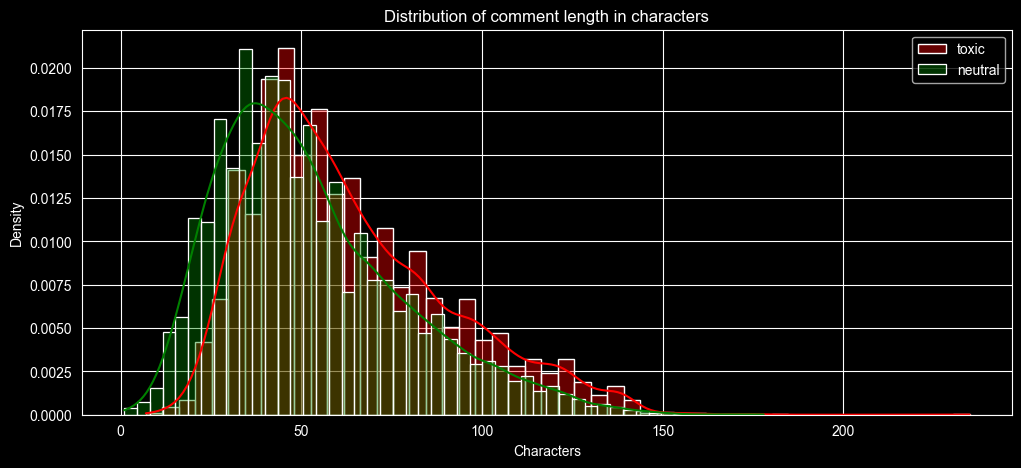

In [70]:
plt.figure(figsize=(12, 5))
sns.histplot(df["toxic_len_chars"], bins=50, color="red", label="toxic", kde=True, stat="density", alpha=0.4)
sns.histplot(df["neutral_len_chars"], bins=50, color="green", label="neutral", kde=True, stat="density", alpha=0.4)
plt.legend()
plt.title("Distribution of comment length in characters")
plt.xlabel("Characters")
plt.ylabel("Density")
plt.savefig(str(output_dir / "character_length_distribution.png"))
plt.show()

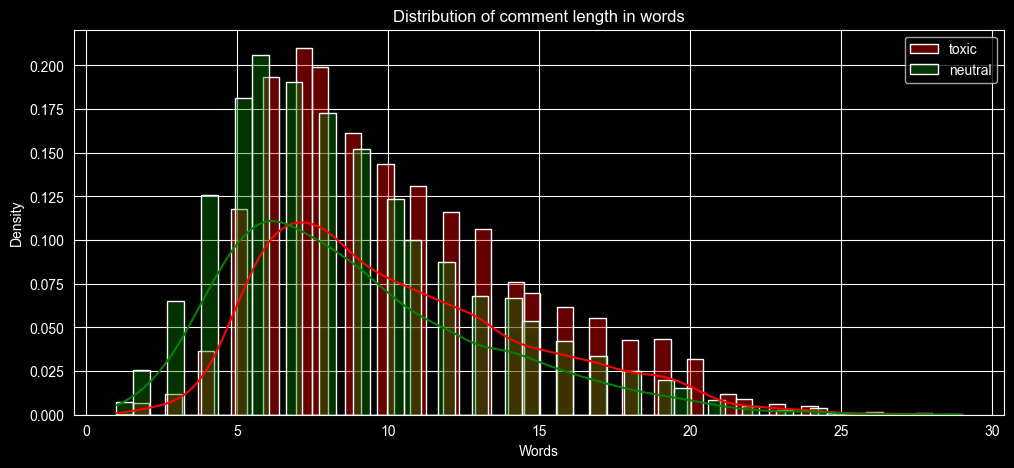

In [71]:
plt.figure(figsize=(12, 5))
sns.histplot(df["toxic_len_words"], bins=50, color="red", label="toxic", kde=True, stat="density", alpha=0.4)
sns.histplot(df["neutral_len_words"], bins=50, color="green", label="neutral", kde=True, stat="density", alpha=0.4)
plt.legend()
plt.title("Distribution of comment length in words")
plt.xlabel("Words")
plt.ylabel("Density")
plt.savefig(str(output_dir / "word_length_distribution.png"))
plt.show()

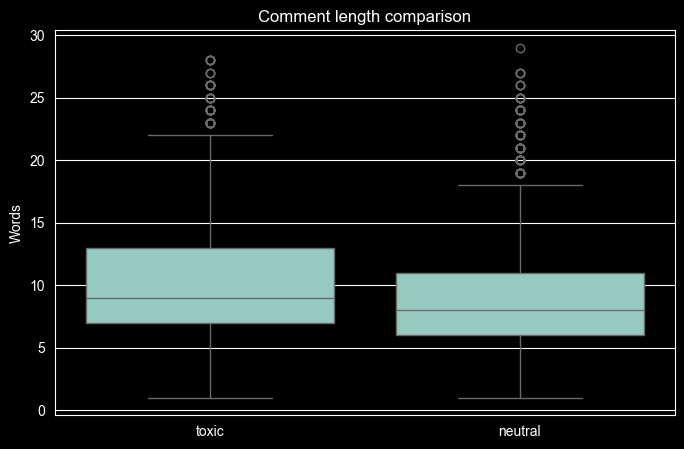

In [72]:
length_df = pd.DataFrame({
    "type": ["toxic"] * len(df) + ["neutral"] * len(df),
    "length_words": list(df["toxic_len_words"]) + list(df["neutral_len_words"])
})

plt.figure(figsize=(8, 5))
sns.boxplot(data=length_df, x="type", y="length_words")
plt.title("Comment length comparison")
plt.xlabel("")
plt.ylabel("Words")
plt.savefig(str(output_dir / "comment_length_comparison.png"))
plt.show()

Проверка самых коротких и длинных примеров

In [73]:
df.sort_values("toxic_len_words").head(10)[["ru_toxic_comment", "ru_neutral_comment", "toxic_len_words"]]

,ru_toxic_comment,ru_neutral_comment,toxic_len_words
6906,ААХАХАХХХАХХ..ПИЗДЕЦ(,ААХАХАХХХАХХ,1
6303,#ERROR!,Лучше не будем ругаться друг на друга. А ты ра...,1
6905,ААХАХАХХХАХХ..ПИЗДЕЦ(,Аахахахххахх,1
7238,"предновогоднее волшебство,сука(",Предновогоднее волшебство,2
6392,ЧТООООООООО?ДО ЯНВАРЯ?ПИЗДЕЦ((ХАХАХАХХА,Неужели до января?,2
7237,"предновогоднее волшебство,сука(",Предновогоднее волшебство,2
6777,ПИЗДЕШОМ ПАХНУЛО(((999,Пахнуло враньем,2
5248,Сука!победитель бля(,победитель однако,2
10685,два фильмодрочера!,Два человека любящие смотреть фильмы,2
10683,ДЫ БЛИИИНННН*(((((ЧИТЕР!!!,Читер,2


In [74]:
df.sort_values("toxic_len_words", ascending=False).head(10)[["ru_toxic_comment", "ru_neutral_comment", "toxic_len_words"]]

,ru_toxic_comment,ru_neutral_comment,toxic_len_words
5793,"Иду на остановку, а на встречу мне хач катится...","Иду на остановку, а на встречу мне нерусский и...",28
7294,ФАААК ! АААА НЕЕЕЕТ ТОЛЬКО НЕ ЭТООО !!!! МОЕГО...,Ужасно! АААА НЕЕЕЕТ ТОЛЬКО НЕ ЭТООО !!!! МОЕГО...,28
5417,"Блять( да что же это такое , я без тебя даже з...","Да что же это, я без тебя заснуть не могу, сто...",28
7295,ФАААК ! АААА НЕЕЕЕТ ТОЛЬКО НЕ ЭТООО !!!! МОЕГО...,АААА НЕЕЕЕТ ТОЛЬКО НЕ ЭТООО !!!! МОЕГО ПЛАТЬЯ ...,28
7218,"Фуух Бля , сдал курсач...протараторил так , чт...","Сдал курсовую. Проговорил так, что сам ничего ...",28
7219,"Фуух Бля , сдал курсач...протараторил так , чт...","Фуух, сдал курсач...протараторил так , что сам...",28
8265,ОМГ я дебил...я упал а мама решил меня придерж...,ОМГ Я упал А мама решила меня придержать и кор...,27
8264,ОМГ я дебил...я упал а мама решил меня придерж...,я упал а мама решил меня придержать и короч уп...,27
6050,"Мало того, что проспала, так блять еще и параш...","Мало того, что я проспала, так ещё и двойку по...",27
9316,"""хорошо"" начался 2014 год!( Одна сука бля, даж...",Хорошо,26


In [75]:
df.sort_values("neutral_len_words").head(10)[["ru_toxic_comment", "ru_neutral_comment", "neutral_len_words"]]

,ru_toxic_comment,ru_neutral_comment,neutral_len_words
8001,ебаный стыд:(((,Стыд,1
5117,"""ЗАТКНИСЬ ТВАРЬ!!!"" ""РУКИ УБЕРИ ДЕРЕВНЯ!"" разг...",Замолчи,1
7610,11 СЕРИЯ ПРОСТО ДУШЕРАЗДИРАЮЩАЯ! Я НЕ МОГУ......,11,1
9382,сука хочу(,хочу(,1
11124,а мы просим тебя иди нахуй,уйди,1
2983,очередной пиздешь. ок тоже становятся помойкой,Ложь,1
5189,вапщи пиздец:((,Ужасно,1
3726,2 пидара и третий гарбатый йух!!!,Два,1
3679,"рот завали,шлюха из борделя! соси лучше молча",Замолчи,1
5278,бля ну вот тут подьебал(,Подколол,1


In [76]:
df.sort_values("neutral_len_words", ascending=False).head(10)[["ru_toxic_comment", "ru_neutral_comment", "neutral_len_words"]]

,ru_toxic_comment,ru_neutral_comment,neutral_len_words
5866,типичная физра:Оля бьёт Сашу. Саша бьёт Олю. О...,типичная физра : Оля бьет Сашу.Саша бьет Олю. ...,29
5920,"ОДИН НЕ РАЗБЕРЁТ,ЧЕМ ПАХНУТ РОЗЫ. ДРУГОЙ ИЗ ГО...","Один не понимает, чем пахнут розы. Другой умее...",27
7294,ФАААК ! АААА НЕЕЕЕТ ТОЛЬКО НЕ ЭТООО !!!! МОЕГО...,Ужасно! АААА НЕЕЕЕТ ТОЛЬКО НЕ ЭТООО !!!! МОЕГО...,27
8265,ОМГ я дебил...я упал а мама решил меня придерж...,ОМГ Я упал А мама решила меня придержать и кор...,27
10902,Данка рассталась со своим( пиздец....родная я ...,Данка рассталась со своим .родная я с тобой .т...,27
9202,"потому что ты мудакМб я пошлый, но не настольк...",Потому что ты не очень хороший человек. Может ...,26
8469,"та ты шо, смотрю на фотки тех кто уже женился....","Та ты шо.. Смотрю на фотки тех, кто уже женилс...",26
8604,Я тут подумал. ЕСЛИ БЫ НА КОНЦЕ ГВОЗДИКА НЕ БЫ...,Я тут подумал. ЕСЛИ БЫ НА КОНЦЕ ГВОЗДИКА НЕ БЫ...,26
10901,Данка рассталась со своим( пиздец....родная я ...,"Данка рассталась со своим( ужас… родная, я с т...",26
8264,ОМГ я дебил...я упал а мама решил меня придерж...,я упал а мама решил меня придержать и короч уп...,25


Доля изменений между toxic и neutral

In [77]:
def token_overlap(a, b):
    a_set = set(str(a).lower().split())
    b_set = set(str(b).lower().split())
    if len(a_set) == 0 or len(b_set) == 0:
        return 0
    return len(a_set & b_set) / len(a_set | b_set)

df["token_overlap"] = df.apply(lambda row: token_overlap(row["ru_toxic_comment"], row["ru_neutral_comment"]), axis=1)
df["token_overlap"].describe()

count    12206.000000
mean         0.473784
std          0.234608
min          0.000000
25%          0.300000
50%          0.461538
75%          0.666667
max          1.000000
Name: token_overlap, dtype: float64

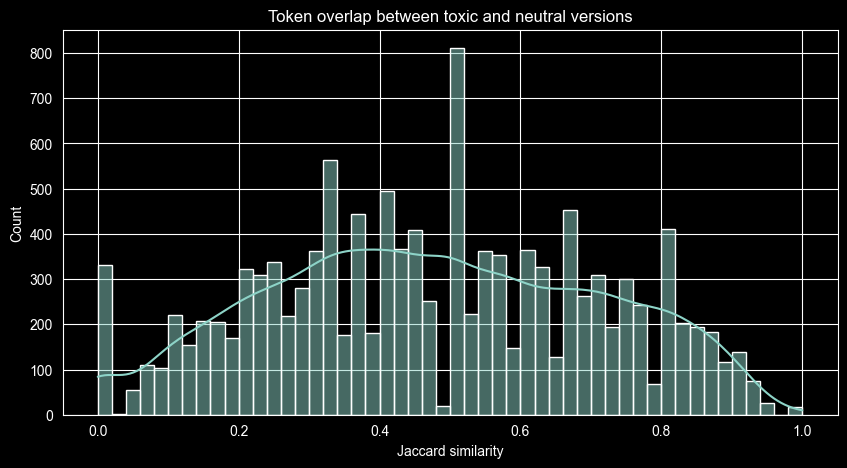

In [78]:
plt.figure(figsize=(10, 5))
sns.histplot(df["token_overlap"], bins=50, kde=True)
plt.title("Token overlap between toxic and neutral versions")
plt.xlabel("Jaccard similarity")
plt.ylabel("Count")
plt.savefig(str(output_dir / "token_overlap.png"))
plt.show()

Разница в длине между токсичным и нейтральным текстом

In [79]:
df["len_diff_words"] = df["toxic_len_words"] - df["neutral_len_words"]
df["len_diff_chars"] = df["toxic_len_chars"] - df["neutral_len_chars"]

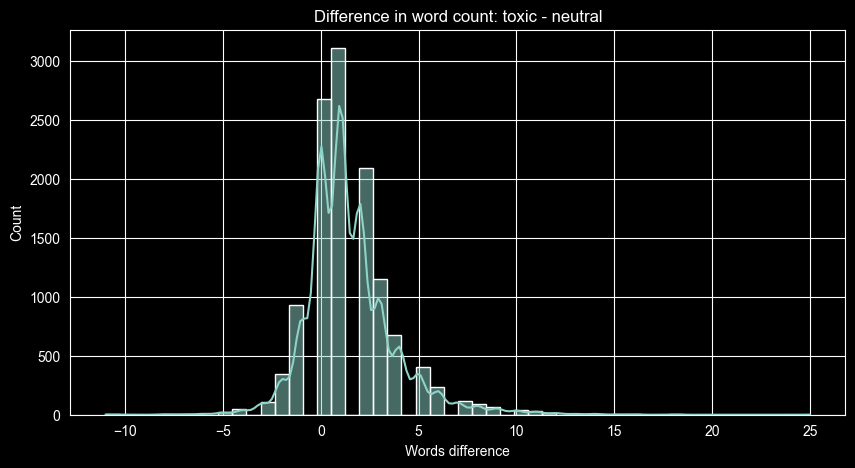

In [80]:
plt.figure(figsize=(10, 5))
sns.histplot(df["len_diff_words"], bins=50, kde=True)
plt.title("Difference in word count: toxic - neutral")
plt.xlabel("Words difference")
plt.ylabel("Count")
plt.savefig(str(output_dir / "difference_in_word_count.png"))
plt.show()

Частотный анализ слов

In [81]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"[^а-яёa-z0-9\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [82]:
df["toxic_clean"] = df["ru_toxic_comment"].apply(preprocess_text)
df["neutral_clean"] = df["ru_neutral_comment"].apply(preprocess_text)

In [83]:
toxic_words = " ".join(df["toxic_clean"]).split()
neutral_words = " ".join(df["neutral_clean"]).split()

toxic_counter = Counter(toxic_words)
neutral_counter = Counter(neutral_words)

In [84]:
print("Top toxic words:")
print(toxic_counter.most_common(20))

Top toxic words:
[('не', 3782), ('и', 3054), ('я', 2829), ('в', 2353), ('а', 1955), ('на', 1788), ('что', 1630), ('ты', 1551), ('как', 1316), ('это', 1087), ('с', 1065), ('пиздец', 919), ('меня', 911), ('у', 844), ('за', 823), ('мне', 802), ('все', 798), ('так', 780), ('ну', 765), ('сука', 748)]


In [85]:
print("Top neutral words:")
print(neutral_counter.most_common(20))

Top neutral words:
[('не', 4071), ('я', 2687), ('и', 2624), ('в', 2069), ('а', 1734), ('что', 1710), ('на', 1527), ('ты', 1257), ('как', 1091), ('это', 1041), ('с', 977), ('меня', 912), ('мне', 871), ('у', 816), ('все', 810), ('так', 789), ('за', 693), ('он', 639), ('же', 567), ('то', 532)]


График самых частых слов

In [86]:
top_toxic = pd.DataFrame(toxic_counter.most_common(20), columns=["word", "count"])
top_neutral = pd.DataFrame(neutral_counter.most_common(20), columns=["word", "count"])

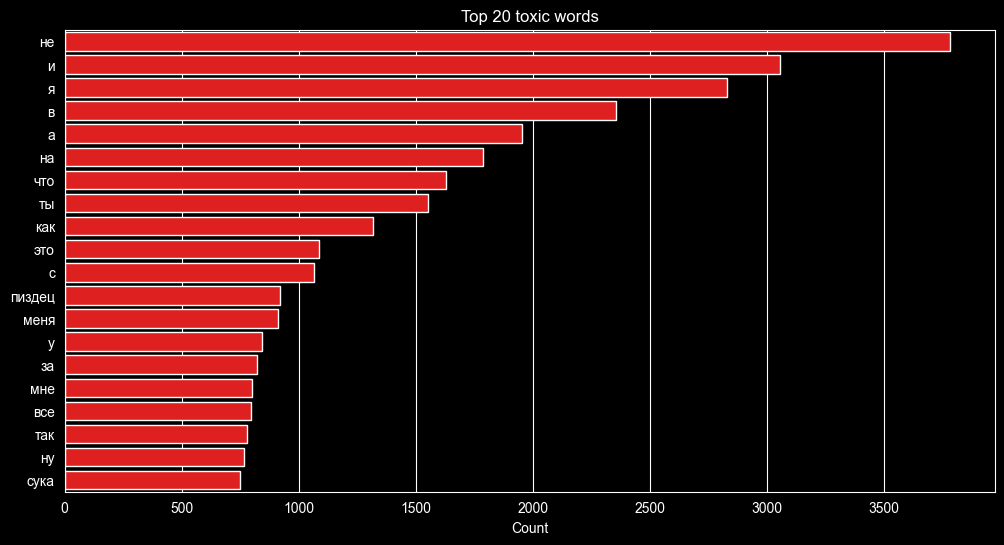

In [87]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_toxic, y="word", x="count", color="red")
plt.title("Top 20 toxic words")
plt.xlabel("Count")
plt.ylabel("")
plt.savefig(str(output_dir / "top_20_words_in_toxic.png"))
plt.show()

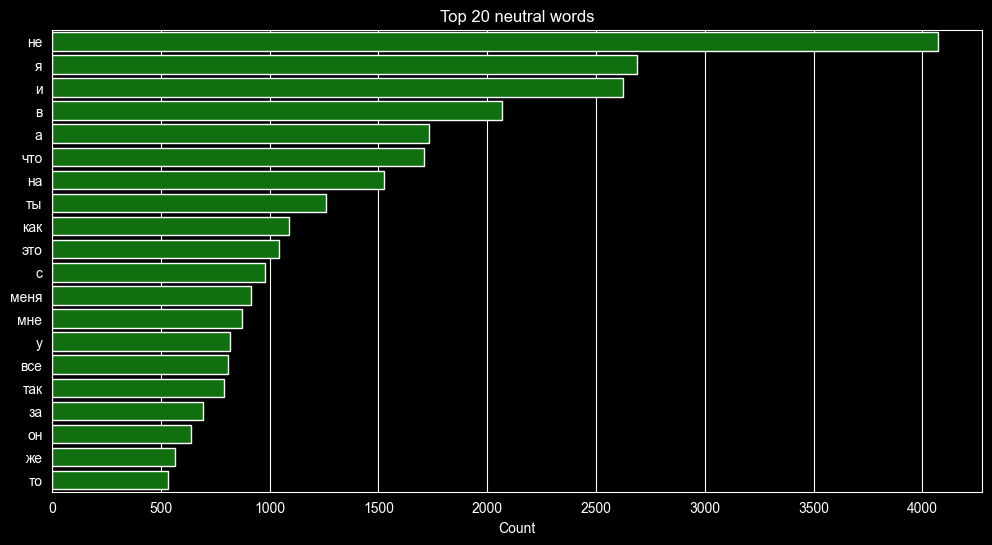

In [88]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_neutral, y="word", x="count", color="green")
plt.title("Top 20 neutral words")
plt.xlabel("Count")
plt.ylabel("")
plt.savefig(str(output_dir / "top_20_words_in_neutral.png"))
plt.show()

Самые частые биграммы

In [89]:
def get_top_ngrams(text_series, n=2, top_k=20):
    vectorizer = CountVectorizer(ngram_range=(n, n))
    X = vectorizer.fit_transform(text_series)
    freqs = X.sum(axis=0).A1
    ngrams = vectorizer.get_feature_names_out()
    result = pd.DataFrame({"ngram": ngrams, "count": freqs})
    return result.sort_values("count", ascending=False).head(top_k)

In [90]:
top_toxic_bigrams = get_top_ngrams(df["toxic_clean"], n=2, top_k=20)
top_toxic_bigrams

,ngram,count
26222,не могу,149
17159,как же,132
16090,из за,131
52431,что за,127
52713,что ты,97
24081,на хуй,84
54089,это не,78
52703,что то,78
32706,пиздец как,76
35581,потому что,75


In [91]:
top_neutral_bigrams = get_top_ngrams(df["neutral_clean"], n=2, top_k=20)
top_neutral_bigrams

,ngram,count
24777,не могу,142
14391,из за,136
27029,ничего не,129
50169,что ты,124
15473,как же,123
5385,все равно,112
50159,что то,106
51342,это не,89
49842,что за,88
25698,не хочу,85


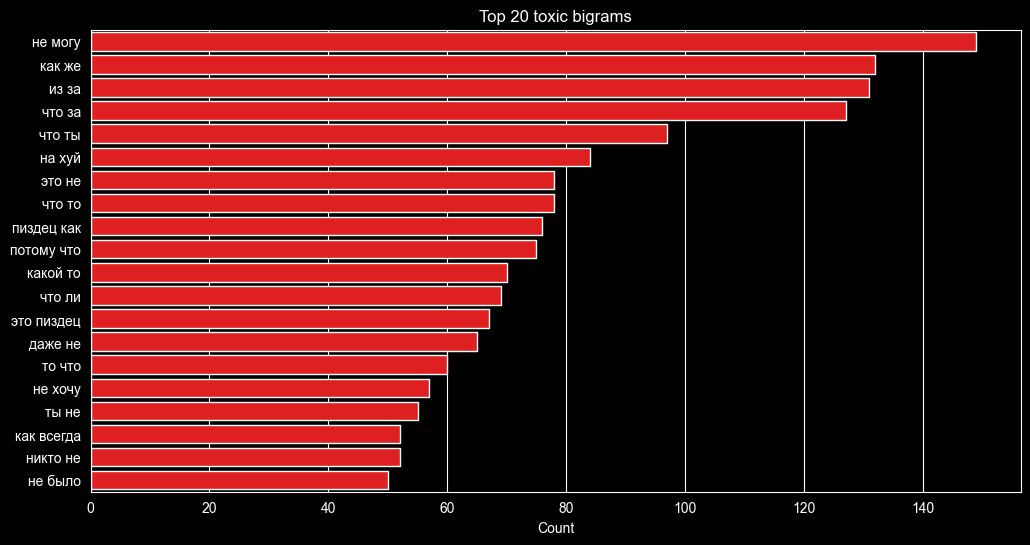

In [92]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_toxic_bigrams, y="ngram", x="count", color="red")
plt.title("Top 20 toxic bigrams")
plt.xlabel("Count")
plt.ylabel("")
plt.savefig(str(output_dir / "top_20_toxic_bigrams.png"))
plt.show()

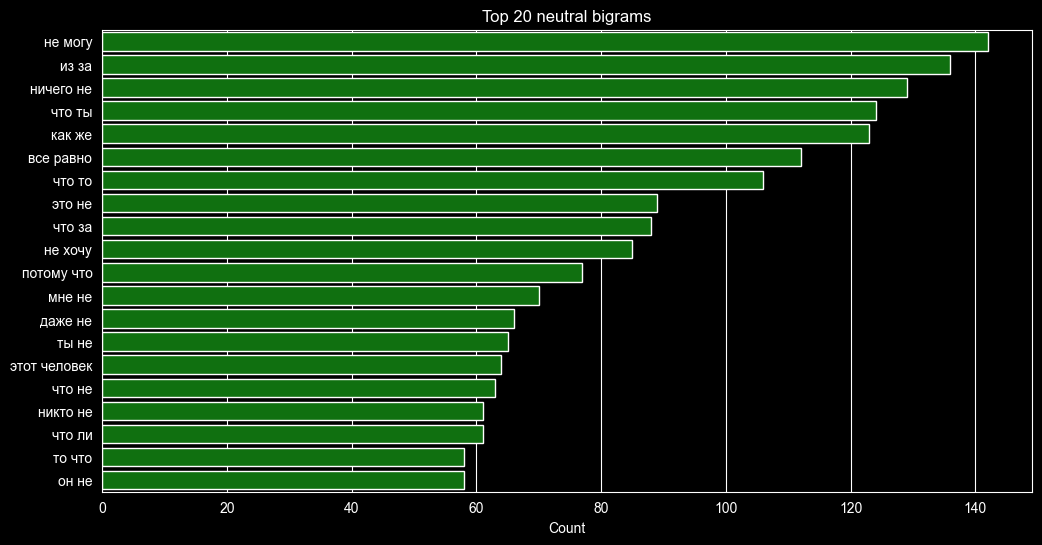

In [93]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_neutral_bigrams, y="ngram", x="count", color="green")
plt.title("Top 20 neutral bigrams")
plt.xlabel("Count")
plt.ylabel("")
plt.savefig(str(output_dir / "top_20_neutral_bigrams.png"))
plt.show()